# Frota EV no Brasil × infraestrutura pública de recarga

**Frente 1 — Opção C (análise de dados públicos) · Enterprise Challenge 2026 FIAP × GoodWe · EV ChargeOps**

**Pergunta da análise:** a frota eletrificada brasileira cresce mais rápido do que a infraestrutura pública de recarga? E o que isso implica para a recarga compartilhada em condomínios — o problema que o EV ChargeOps ataca?

**Método.** Três blocos de dados públicos:

1. **Série anual de emplacamentos** de eletrificados leves (ABVE), transcrita manualmente dos releases oficiais — a ABVE não publica dataset estruturado aberto;
2. **Fotografias da rede pública de recarga** em três cortes (fev/2025, ago/2025, fev/2026), de releases ABVE/Tupi Mobilidade e cobertura especializada que cita esses dados;
3. **Base colaborativa Open Charge Map** (espelho oficial `ocm-export`, sem autenticação), cruzada com a lista de municípios do IBGE, para a distribuição geográfica dos pontos.

**Reprodutibilidade.** As células de download salvam os dados brutos em `data/` e são puladas se os arquivos já existirem; as células de análise leem somente de `data/`. Para refazer do zero, apague `data/ocm_br_poi.json` e `data/ibge_municipios.json` e execute o notebook inteiro. Os gráficos são exportados para `assets/frota-ev-*.png`.

**Fontes (todas acessadas em 2026-06-09):**

| # | Fonte | O que fornece | URL |
|---|---|---|---|
| 1 | ABVE — release jan/2026 | Emplacamentos 2025 (223.912), 2024 (177.358) e 2016 (1.091); divisão BEV/PHEV/HEV 2024–2025 | <https://abve.org.br/eletrificados-crescem-dez-vezes-mais-do-que-conjunto-do-mercado-em-2025-com-224-mil-veiculos-vendidos/> |
| 2 | ABVE — release jan/2022 | Emplacamentos 2019–2021; divisão por tecnologia em 2021 | <https://abve.org.br/eletrificados-batem-todas-as-previsoes-em-2021/> |
| 3 | Fecombustíveis (reprodução de O Globo, 04/01/2024) | Emplacamentos 2022 (49.245) e 2023 (93.927), dados ABVE | <https://www.fecombustiveis.org.br/noticia/venda-de-carros-eletrificados-no-brasil-cresce-91-em-2023-e-atinge-939-mil-emplacamentos/255655> |
| 4 | ABVE — release mar/2026 | Rede de recarga em fev/2025 e fev/2026 (divisão AC/DC), municípios atendidos por região, frota plug-in circulante (411.869), razão 19,6 veículos/ponto e referência ideal 10:1 | <https://abve.org.br/recarga-publica-rapida-cresce-167-em-12-meses-e-ja-atinge-31-dos-21-mil-eletropostos-da-rede/> |
| 5 | ClimaInfo (18/09/2025) | Rede em ago/2025 (16.880 pontos) e frota plug-in em ago/2025 (302.225), dados ABVE/Tupi | <https://climainfo.org.br/2025/09/18/pontos-de-recarga-de-ves-crescem-59-no-brasil-mas-distribuicao-e-desigual/> |
| 6 | Latam Mobility | Divisão AC/DC da rede em 31/08/2025 (13.025 CA / 3.855 CC) | <https://latamobility.com/pt-br/o-brasil-alcanca-16-880-pontos-de-recarga-publicos-e-semipublicos-para-veiculos-eletricos/> |
| 7 | AutoIndústria (24/02/2026) | Concentração estadual da rede: SP com 4.777 pontos (28,3%); SP+RJ+RS+DF somam mais da metade | <https://www.autoindustria.com.br/2026/02/24/a-nova-geografia-da-recarga-eletrica-no-brasil/> |
| 8 | Open Charge Map — `ocm-export` | 1.298 pontos de recarga no BR, georreferenciados (espelho oficial do projeto no GitHub) | <https://github.com/openchargemap/ocm-export> |
| 9 | IBGE — API de localidades | Lista oficial dos 5.571 municípios com UF e região | <https://servicodados.ibge.gov.br/api/v1/localidades/municipios?view=nivelado> |


In [1]:
import gzip
import json
import subprocess
import tempfile
import unicodedata
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# O notebook roda a partir de notebooks/; detecta a raiz do repositório
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA = ROOT / 'data'
ASSETS = ROOT / 'assets'
ASSETS.mkdir(exist_ok=True)

# Paleta: uma cor de destaque para o argumento central, neutros para o resto
CINZA = '#9aa5b1'
AZUL = '#33658a'
DESTAQUE = '#d1495b'

plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})


def br(n):
    """Formata milhar com ponto (1.234.567), padrão brasileiro."""
    return f'{n:,.0f}'.replace(',', '.')


def salvar(fig, nome):
    caminho = ASSETS / nome
    fig.savefig(caminho, dpi=150, bbox_inches='tight')
    print(f'Gráfico salvo em {caminho}')


## 1. Frota: emplacamentos anuais de eletrificados leves (ABVE)

A ABVE divulga os números em releases mensais/anuais (HTML), não em CSV aberto. A série abaixo foi **transcrita manualmente** desses releases — cada número tem a fonte comentada no código, para auditoria. Definições:

- **Eletrificados leves** = automóveis e comerciais leves BEV + PHEV + HEV (incl. HEV flex), critério da ABVE;
- **Plug-in** = BEV + PHEV, o subconjunto que efetivamente depende de tomada — o que interessa ao problema de recarga em condomínio.


In [2]:
# Emplacamentos anuais de veículos eletrificados leves no Brasil (unidades)
# Transcrição manual de releases da ABVE — fonte por linha:
VENDAS = {
    2019: 11_858,   # Fonte 2 (ABVE, jan/2022): "195% sobre os 11.858 de 2019"
    2020: 19_745,   # Fonte 2 (ABVE, jan/2022): "77% sobre os 19.745 emplacamentos de 2020"
    2021: 34_990,   # Fonte 2 (ABVE, jan/2022): "recorde absoluto de 34.990 unidades"
    2022: 49_245,   # Fonte 3 (O Globo/Fecombustíveis, 04/01/2024, dados ABVE)
    2023: 93_927,   # Fonte 3 (idem): "93.927 emplacamentos, +91% sobre 2022"
    2024: 177_358,  # Fonte 1 (ABVE, jan/2026)
    2025: 223_912,  # Fonte 1 (ABVE, jan/2026): "recorde histórico, +26% sobre 2024"
}

# Subconjunto plug-in (BEV + PHEV), nos anos em que a divisão foi publicada:
PLUGIN = {
    2021: 11_461 + 2_851,    # Fonte 2: PHEV 11.461 + BEV 2.851
    2024: 64_009 + 61_615,   # Fonte 1: PHEV 64.009 + BEV 61.615
    2025: 101_364 + 80_178,  # Fonte 1: PHEV 101.364 + BEV 80.178
}
# Obs.: em 2016 foram 1.091 eletrificados no ano inteiro (Fonte 1) — base da
# comparação "20.423% de crescimento em nove anos" feita pela própria ABVE.

frota = pd.DataFrame({'emplacamentos': VENDAS})
frota.index.name = 'ano'
frota['crescimento_aa'] = frota['emplacamentos'].pct_change().map(
    lambda v: f'{v:+.1%}'.replace('.', ',') if pd.notna(v) else '—')
frota['plugin'] = pd.Series(PLUGIN)
frota['share_plugin'] = (frota['plugin'] / frota['emplacamentos']).map(
    lambda v: f'{v:.1%}'.replace('.', ',') if pd.notna(v) else 'n/d')

anos = sorted(VENDAS)
fator = VENDAS[anos[-1]] / VENDAS[anos[0]]
cagr = fator ** (1 / (anos[-1] - anos[0])) - 1
print(f'Crescimento {anos[0]}→{anos[-1]}: {fator:.1f}x | CAGR: {cagr:+.1%}')
frota


Crescimento 2019→2025: 18.9x | CAGR: +63.2%


,emplacamentos,crescimento_aa,plugin,share_plugin
ano,,,,
2019,11858,—,NaN,n/d
2020,19745,"+66,5%",NaN,n/d
2021,34990,"+77,2%",14312.0,"40,9%"
2022,49245,"+40,7%",NaN,n/d
2023,93927,"+90,7%",NaN,n/d
2024,177358,"+88,8%",125624.0,"70,8%"
2025,223912,"+26,2%",181542.0,"81,1%"


## 2. Rede pública de recarga e frota plug-in circulante (ABVE/Tupi Mobilidade)

A base nacional de eletropostos é mantida pela ABVE em parceria com a Tupi Mobilidade e divulgada em releases — também transcrita manualmente, em três cortes temporais. Conceitos:

- **Pontos públicos e semipúblicos** cadastrados (não inclui carregadores residenciais privados);
- **Razão veículos/ponto**: numerador = frota plug-in acumulada em circulação (BEV+PHEV, estimativa ABVE); denominador = pontos públicos e semipúblicos. A própria ABVE adota **10 veículos por ponto** como referência de rede adequada;
- Limitação explícita: a razão compara um estoque (frota) com a rede *pública* — ela ignora a recarga privada/residencial e serve como **indicador de pressão sobre a infraestrutura compartilhada**, não como medida de cobertura total.


In [3]:
# Rede pública/semipública de recarga (pontos), por tipo de carregador
# Transcrição manual — fontes 4 (fev/2025 e fev/2026), 5 e 6 (ago/2025):
REDE = pd.DataFrame({
    'AC (lentos)':       {'fev/2025': 12_397, 'ago/2025': 13_025, 'fev/2026': 14_582},
    'DC (rápidos)':      {'fev/2025': 2_430,  'ago/2025': 3_855,  'fev/2026': 6_479},
}).loc[['fev/2025', 'ago/2025', 'fev/2026']]
REDE['total'] = REDE.sum(axis=1)
# Conferência contra os totais publicados: ago/2025 = 16.880 (fontes 5 e 6);
# fev/2026 = 21.061 (fonte 4)
assert REDE.loc['ago/2025', 'total'] == 16_880
assert REDE.loc['fev/2026', 'total'] == 21_061

# Frota plug-in acumulada em circulação (BEV + PHEV), estimativa ABVE:
FROTA_PLUGIN = {
    'ago/2025': 302_225,  # Fonte 5 (ClimaInfo, dados ABVE/Tupi)
    'fev/2026': 411_869,  # Fonte 4 (ABVE)
}
RAZAO_IDEAL = 10  # referência adotada pela ABVE (fonte 4)

razao = pd.DataFrame({'frota_plugin': FROTA_PLUGIN})
razao['pontos'] = REDE['total']
razao['veiculos_por_ponto'] = (razao['frota_plugin'] / razao['pontos']).round(1)

# Municípios com ao menos um ponto de recarga, por região (fev/2026, fonte 4):
MUNICIPIOS_REGIAO = {'Sudeste': 580, 'Sul': 423, 'Nordeste': 412,
                     'Centro-Oeste': 152, 'Norte': 82}
total_municipios_atendidos = sum(MUNICIPIOS_REGIAO.values())  # 1.649

cresc_frota = FROTA_PLUGIN['fev/2026'] / FROTA_PLUGIN['ago/2025'] - 1
cresc_rede = REDE.loc['fev/2026', 'total'] / REDE.loc['ago/2025', 'total'] - 1
print(f'ago/2025 → fev/2026 (6 meses): frota plug-in {cresc_frota:+.1%} | '
      f'rede pública {cresc_rede:+.1%}')
print(f'Municípios com infraestrutura (fev/2026): {total_municipios_atendidos} '
      f'de 5.571 ({total_municipios_atendidos/5_571:.1%})')
razao


ago/2025 → fev/2026 (6 meses): frota plug-in +36.3% | rede pública +24.8%
Municípios com infraestrutura (fev/2026): 1649 de 5.571 (29.6%)


,frota_plugin,pontos,veiculos_por_ponto
ago/2025,302225,16880,17.9
fev/2026,411869,21061,19.6


## 3. Open Charge Map + IBGE: distribuição geográfica dos pontos

A API oficial do Open Charge Map (`https://api.openchargemap.io/v3/poi?countrycode=BR`) **exige chave de API** — ela é gratuita (basta criar conta em <https://map.openchargemap.io> e gerar a chave em "My Apps"; documentação em <https://openchargemap.org/site/develop/api>), mas para manter o notebook reproduzível **sem credenciais** usamos o espelho oficial do projeto no GitHub (`openchargemap/ocm-export`), que publica um JSON por ponto de recarga. Baixamos apenas o diretório `data/BR` via clone esparso (~1,3 mil arquivos; último commit do espelho na data do download: 2026-04-22) e consolidamos tudo em `data/ocm_br_poi.json`.

**Qualidade do dado:** cerca de 42% dos pontos brasileiros vêm sem o campo de UF (`StateOrProvince`) preenchido, e o preenchimento é texto livre ("SP", "São Paulo", "Sao Paulo", até o typo "Too de Janeiro"). O tratamento, na seção seguinte: normalização de grafia + recuperação da UF pelo nome do município (`Town`) contra a lista oficial do IBGE, aplicada somente quando o nome do município é único no país.


In [4]:
OCM_PATH = DATA / 'ocm_br_poi.json'
IBGE_PATH = DATA / 'ibge_municipios.json'

if OCM_PATH.exists():
    print(f'OK: {OCM_PATH.name} já existe — download pulado.')
else:
    print('Baixando Open Charge Map (espelho oficial ocm-export, somente data/BR)...')
    with tempfile.TemporaryDirectory() as tmp:
        repo = Path(tmp) / 'ocm'
        subprocess.run(
            ['git', 'clone', '--depth', '1', '--filter=blob:none', '--sparse',
             'https://github.com/openchargemap/ocm-export.git', str(repo)],
            check=True, capture_output=True)
        subprocess.run(
            ['git', '-C', str(repo), 'sparse-checkout', 'set', 'data/BR'],
            check=True, capture_output=True)
        pois = []
        for arq in sorted((repo / 'data' / 'BR').glob('OCM-*.json')):
            d = json.loads(arq.read_text())
            ai = d.get('AddressInfo') or {}
            pois.append({
                'ID': d.get('ID'),
                'Title': ai.get('Title'),
                'Town': ai.get('Town'),
                'StateOrProvince': ai.get('StateOrProvince'),
                'Latitude': ai.get('Latitude'),
                'Longitude': ai.get('Longitude'),
                'NumberOfPoints': d.get('NumberOfPoints'),
                'NumConnections': len(d.get('Connections') or []),
                'DateLastStatusUpdate': d.get('DateLastStatusUpdate'),
            })
    OCM_PATH.write_text(json.dumps(pois, ensure_ascii=False))
    print(f'OK: {len(pois)} pontos salvos em {OCM_PATH}')

if IBGE_PATH.exists():
    print(f'OK: {IBGE_PATH.name} já existe — download pulado.')
else:
    print('Baixando lista de municípios do IBGE...')
    url = ('https://servicodados.ibge.gov.br/api/v1/localidades/'
           'municipios?view=nivelado')
    with urllib.request.urlopen(url, timeout=60) as resp:
        bruto = resp.read()
    if bruto[:2] == b'\x1f\x8b':  # o servidor do IBGE pode responder gzip
        bruto = gzip.decompress(bruto)
    IBGE_PATH.write_bytes(bruto)
    print(f'OK: salvo em {IBGE_PATH}')


Baixando Open Charge Map (espelho oficial ocm-export, somente data/BR)...


OK: 1298 pontos salvos em /home/ubuntu/projects/challenge_2026/data/ocm_br_poi.json
Baixando lista de municípios do IBGE...
OK: salvo em /home/ubuntu/projects/challenge_2026/data/ibge_municipios.json


In [5]:
faltantes = [p.name for p in (OCM_PATH, IBGE_PATH) if not p.exists()]
if faltantes:
    raise FileNotFoundError(
        f'Arquivos brutos ausentes em data/: {faltantes}. '
        'Execute a célula de download acima antes de prosseguir.')

ocm = pd.DataFrame(json.loads(OCM_PATH.read_text()))
ibge = pd.DataFrame(json.loads(IBGE_PATH.read_text()))
print(f'OCM: {len(ocm)} pontos de recarga | IBGE: {len(ibge)} municípios')
ocm.head(3)


OCM: 1298 pontos de recarga | IBGE: 5571 municípios


,ID,Title,Town,StateOrProvince,Latitude,Longitude,NumberOfPoints,NumConnections,DateLastStatusUpdate
0,154527,Floripa Shopping,Florianópolis,Santa Catarina,-27.534451,-48.509559,2.0,1,2020-03-17T08:10:00Z
1,154528,Estação Posto Ilhabela,Florianópolis,Santa Catarina,-27.578139,-48.510338,2.0,3,2020-03-17T08:17:00Z
2,15468,Petrobras Future Station Service,Rio de Janeiro,Rio de Janeiro,-23.000385,-43.350854,1.0,1,2021-08-24T17:46:00Z


In [6]:
def normalizar(s):
    """minúsculas, sem acentos, sem pontuação nas bordas."""
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode()
    return ' '.join(s.lower().strip(' ,.').split())


# Tabelas de consulta a partir do IBGE
UF_INFO = ibge.drop_duplicates('UF-sigla').set_index('UF-sigla')[
    ['UF-nome', 'regiao-nome']]
NOME2UF = {normalizar(nome): sigla
           for sigla, nome in UF_INFO['UF-nome'].items()}

# município (nome normalizado) -> UF, apenas quando o nome é único no país
mun_grupos = ibge.groupby(ibge['municipio-nome'].map(normalizar))['UF-sigla']
MUN2UF = {nome: g.iloc[0] for nome, g in mun_grupos if g.nunique() == 1}

# Grafias irregulares encontradas na base OCM, mapeadas manualmente após
# inspeção dos valores não reconhecidos (texto livre de base colaborativa):
ALIASES = {
    'too de janeiro': 'RJ',                       # typo de "Rio de Janeiro"
    'federal district': 'DF',
    'regiao metropolitana de sao paulo': 'SP',
    'metropolitan region of porto alegre': 'RS',
    'regiao metropolitana de campina grande': 'PB',
    'regiao metropolitana de guarabira': 'PB',
    'indaiatuba - sp': 'SP',
    'corrente/pi': 'PI',
    'barreiras - ba': 'BA',
    'brasileia': 'AC',                            # município do Acre
    'rio grande del sur': 'RS',
    'camocim': 'CE',                              # município do Ceará
}


def uf_do_ponto(linha):
    bruto = linha['StateOrProvince']
    bruto = '' if pd.isna(bruto) else str(bruto).strip()
    if bruto:
        n = normalizar(bruto)
        if len(n) == 2 and n.upper() in UF_INFO.index:
            return n.upper(), 'campo estado'
        if n in NOME2UF:
            return NOME2UF[n], 'campo estado'
        if n in ALIASES:
            return ALIASES[n], 'campo estado'
    cidade = linha['Town']
    cidade = '' if pd.isna(cidade) else normalizar(cidade)
    if cidade in MUN2UF:
        return MUN2UF[cidade], 'município (IBGE)'
    return None, 'não identificado'


resultado = ocm.apply(uf_do_ponto, axis=1, result_type='expand')
ocm['UF'], ocm['origem_uf'] = resultado[0], resultado[1]
ocm['regiao'] = ocm['UF'].map(UF_INFO['regiao-nome'])

print(ocm['origem_uf'].value_counts().to_string())
identificados = ocm.dropna(subset=['UF'])
por_uf = identificados['UF'].value_counts()
por_regiao = identificados['regiao'].value_counts()
n_nd = len(ocm) - len(identificados)
print(f'\nIdentificados: {len(identificados)} de {len(ocm)} '
      f'({len(identificados)/len(ocm):.1%}) | sem UF: {n_nd}')
print('\nPor região (% dos identificados):')
print((por_regiao / len(identificados)).map(lambda v: f'{v:.1%}').to_string())


origem_uf
campo estado        755
município (IBGE)    482
não identificado     61

Identificados: 1237 de 1298 (95.3%) | sem UF: 61

Por região (% dos identificados):
regiao
Sudeste         41.6%
Nordeste        23.5%
Centro-Oeste    17.6%
Sul             15.6%
Norte            1.6%


## Gráfico 1 — Crescimento da frota: 19× em seis anos

Os emplacamentos anuais de eletrificados leves saíram de 11.858 (2019) para 223.912 (2025) — fator de 18,9×, CAGR de +63% ao ano, contra +2,6% do mercado total de veículos em 2025 (fonte 1). E a composição mudou: a fatia **plug-in** (que depende de tomada) saltou de 41% das vendas em 2021 para 71% em 2024 e **81% em 2025**. O crescimento da frota é, cada vez mais, crescimento de demanda por recarga.


Gráfico salvo em /home/ubuntu/projects/challenge_2026/assets/frota-ev-vendas-anuais.png


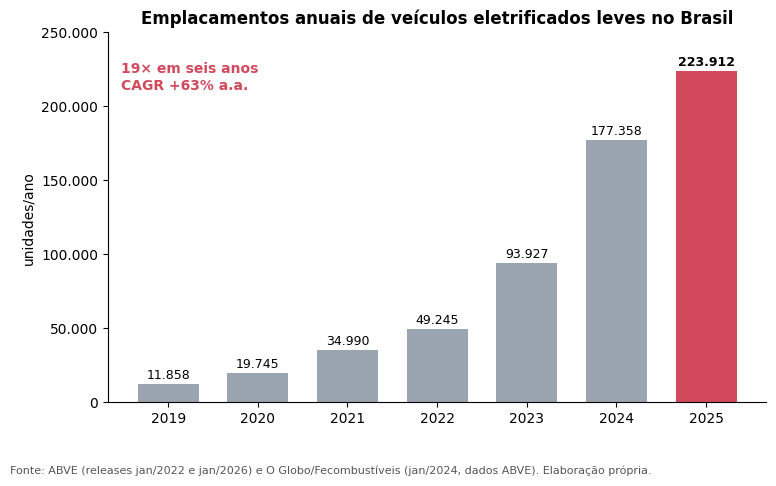

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
anos = list(VENDAS)
valores = [VENDAS[a] for a in anos]
cores = [DESTAQUE if a == 2025 else CINZA for a in anos]
ax.bar([str(a) for a in anos], valores, color=cores, width=0.68)
for i, v in enumerate(valores):
    ax.annotate(br(v), (i, v), textcoords='offset points', xytext=(0, 4),
                ha='center', fontsize=9,
                fontweight='bold' if anos[i] == 2025 else 'normal')
ax.set_title('Emplacamentos anuais de veículos eletrificados leves no Brasil')
ax.set_ylabel('unidades/ano')
ax.set_ylim(0, 250_000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: br(v)))
ax.text(0.02, 0.92, f'{valores[-1]/valores[0]:.0f}× em seis anos\n'
        f'CAGR {cagr:+.0%} a.a.', transform=ax.transAxes, fontsize=10,
        va='top', color=DESTAQUE, fontweight='bold')
fig.text(0.01, -0.04, 'Fonte: ABVE (releases jan/2022 e jan/2026) e O Globo/'
         'Fecombustíveis (jan/2024, dados ABVE). Elaboração própria.',
         fontsize=8, color='#555555')
salvar(fig, 'frota-ev-vendas-anuais.png')
plt.show()


## Gráfico 2 — Onde está a rede pública: distribuição por UF (amostra Open Charge Map)

Distribuição **autoral** a partir dos 1.298 pontos brasileiros da base colaborativa Open Charge Map. Dois cuidados de leitura:

- **Subcontagem**: a base oficial ABVE/Tupi registra 21.061 pontos (fev/2026); o OCM cobre ~6% disso. Usamos apenas a **distribuição relativa**, não a contagem absoluta;
- **Viés de contribuição**: base colaborativa reflete onde há contribuidores ativos (ex.: CE aparece acima do peso esperado). Como contraprova, a concentração observada vai na mesma direção da base oficial: SP lidera com 21,7% na amostra OCM vs. 28,3% na base oficial (fonte 7), e SP+RJ+RS+DF somam 45% na amostra vs. "mais da metade" na oficial.


Gráfico salvo em /home/ubuntu/projects/challenge_2026/assets/frota-ev-pontos-por-uf.png


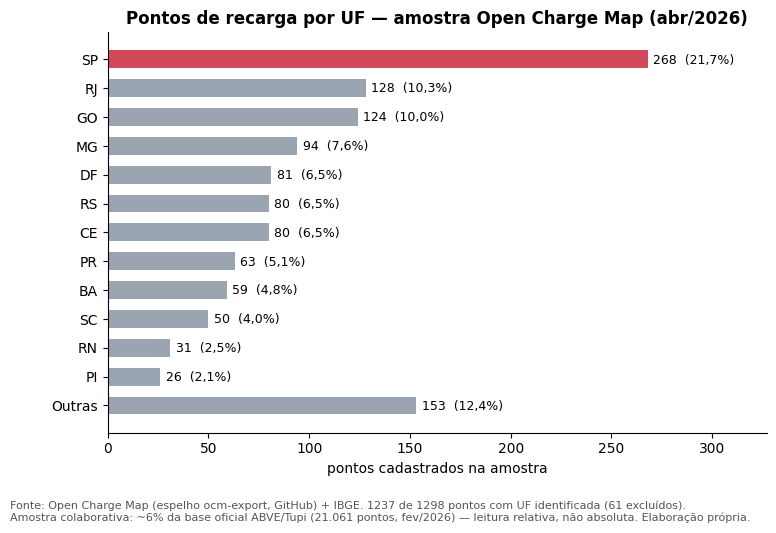

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
top = por_uf.head(12)
outras = por_uf.iloc[12:].sum()
serie = pd.concat([top, pd.Series({'Outras': outras})])[::-1]
cores = [DESTAQUE if uf == 'SP' else CINZA for uf in serie.index]
ax.barh(serie.index, serie.values, color=cores, height=0.62)
for i, (uf, v) in enumerate(serie.items()):
    ax.annotate(f'{v}  ({v/len(identificados):.1%})'.replace('.', ','),
                (v, i), textcoords='offset points', xytext=(4, -3), fontsize=9)
ax.set_title('Pontos de recarga por UF — amostra Open Charge Map (abr/2026)')
ax.set_xlabel('pontos cadastrados na amostra')
ax.set_xlim(0, serie.max() * 1.22)
fig.text(0.01, -0.06,
         f'Fonte: Open Charge Map (espelho ocm-export, GitHub) + IBGE. '
         f'{len(identificados)} de {len(ocm)} pontos com UF identificada '
         f'({n_nd} excluídos).\nAmostra colaborativa: ~6% da base oficial '
         'ABVE/Tupi (21.061 pontos, fev/2026) — leitura relativa, não '
         'absoluta. Elaboração própria.', fontsize=8, color='#555555')
salvar(fig, 'frota-ev-pontos-por-uf.png')
plt.show()


## Gráfico 3 — O gráfico-argumento: a rede cresce em ritmo recorde e a razão veículos/ponto ainda assim piora

Entre ago/2025 e fev/2026 a rede pública viveu sua expansão mais rápida (+25% em seis meses, com os carregadores rápidos DC crescendo 167% em 12 meses). **Mesmo assim**, a frota plug-in cresceu mais (+36% no mesmo semestre), e a razão veículos por ponto público subiu de **17,9 para 19,6** — praticamente o dobro da referência de 10:1 adotada pela ABVE.

Numerador e denominador explícitos: 302.225 / 16.880 (ago/2025) e 411.869 / 21.061 (fev/2026) — frota plug-in circulante estimada ÷ pontos públicos e semipúblicos. A razão não mede a recarga residencial privada; mede a pressão sobre a infraestrutura **compartilhada**.


Gráfico salvo em /home/ubuntu/projects/challenge_2026/assets/frota-ev-razao-veiculos-por-ponto.png


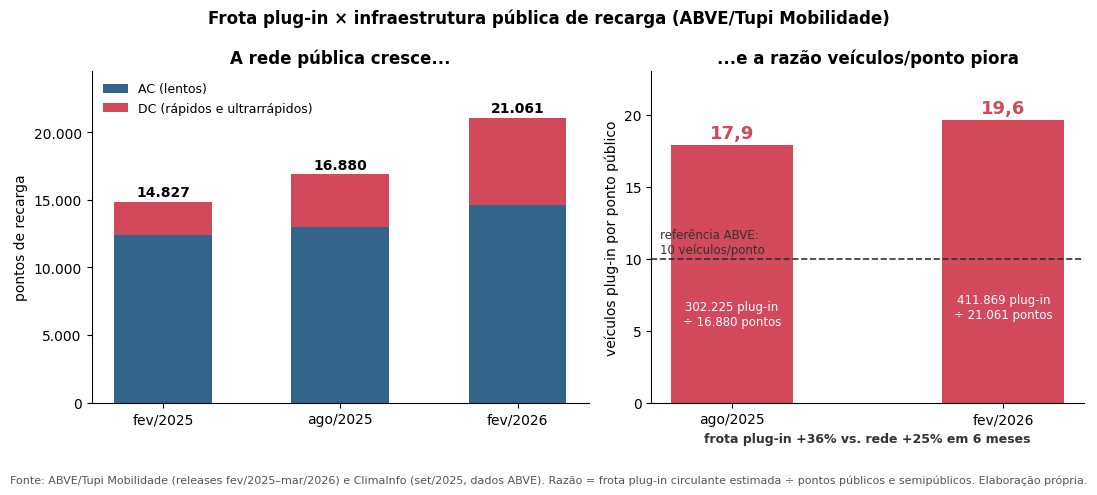

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6),
                               gridspec_kw={'width_ratios': [1.15, 1]})

# Painel A — a rede cresce (empilhado AC/DC)
x = REDE.index.tolist()
ax1.bar(x, REDE['AC (lentos)'], color=AZUL, width=0.55, label='AC (lentos)')
ax1.bar(x, REDE['DC (rápidos)'], bottom=REDE['AC (lentos)'], color=DESTAQUE,
        width=0.55, label='DC (rápidos e ultrarrápidos)')
for i, periodo in enumerate(x):
    ax1.annotate(br(REDE.loc[periodo, 'total']),
                 (i, REDE.loc[periodo, 'total']), textcoords='offset points',
                 xytext=(0, 4), ha='center', fontsize=10, fontweight='bold')
ax1.set_title('A rede pública cresce...')
ax1.set_ylabel('pontos de recarga')
ax1.set_ylim(0, 24_500)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: br(v)))
ax1.legend(frameon=False, loc='upper left', fontsize=9)

# Painel B — ...mas a frota cresce mais rápido
periodos = ['ago/2025', 'fev/2026']
valores_razao = [razao.loc[p, 'veiculos_por_ponto'] for p in periodos]
ax2.bar(periodos, valores_razao, color=DESTAQUE, width=0.45)
for i, p in enumerate(periodos):
    ax2.annotate(str(valores_razao[i]).replace('.', ','),
                 (i, valores_razao[i]), textcoords='offset points',
                 xytext=(0, 5), ha='center', fontsize=13, fontweight='bold',
                 color=DESTAQUE)
    ax2.annotate(f"{br(razao.loc[p, 'frota_plugin'])} plug-in\n÷ "
                 f"{br(razao.loc[p, 'pontos'])} pontos",
                 (i, valores_razao[i] * 0.3), ha='center', fontsize=8.5,
                 color='white')
ax2.axhline(RAZAO_IDEAL, color='#333333', linestyle='--', linewidth=1.2)
ax2.text(0.02, RAZAO_IDEAL + 0.4, 'referência ABVE:\n10 veículos/ponto',
         transform=ax2.get_yaxis_transform(), ha='left', fontsize=8.5,
         color='#333333')
ax2.set_title('...e a razão veículos/ponto piora')
ax2.set_ylabel('veículos plug-in por ponto público')
ax2.set_ylim(0, 23)
ax2.set_xlabel('frota plug-in +36% vs. rede +25% em 6 meses',
               fontsize=9, fontweight='bold', color='#333333')

fig.suptitle('Frota plug-in × infraestrutura pública de recarga (ABVE/Tupi '
             'Mobilidade)', fontweight='bold')
fig.text(0.01, -0.05, 'Fonte: ABVE/Tupi Mobilidade (releases fev/2025–mar/2026) '
         'e ClimaInfo (set/2025, dados ABVE). Razão = frota plug-in circulante '
         'estimada ÷ pontos públicos e semipúblicos. Elaboração própria.',
         fontsize=8, color='#555555')
fig.tight_layout()
salvar(fig, 'frota-ev-razao-veiculos-por-ponto.png')
plt.show()


## Gráfico 4 — Projeção ilustrativa (não é previsão)

Extrapolação geométrica simples dos emplacamentos para 2026–2028, em dois cenários: **A** mantém o ritmo de 2025 (+26% a.a., o mais lento da série); **B** mantém o CAGR 2022–2025 (+66% a.a.). O objetivo é dimensionar **ordens de grandeza** da demanda futura por recarga, não prever o mercado — a trajetória real é sensível a câmbio, tarifas de importação, política industrial e oferta de modelos. Mesmo no cenário conservador, entrariam ~283 mil eletrificados novos só em 2026.


Cenário A (+26.2% a.a.): 282.686 | 356.887 | 450.565
Cenário B (+65.7% a.a.): 370.950 | 614.546 | 1.018.105
Gráfico salvo em /home/ubuntu/projects/challenge_2026/assets/frota-ev-projecao-ilustrativa.png


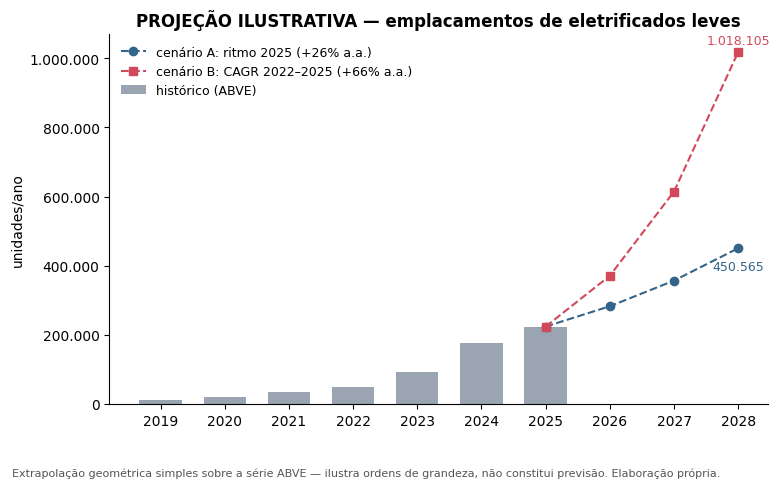

In [10]:
g_a = VENDAS[2025] / VENDAS[2024] - 1                  # ritmo de 2025
g_b = (VENDAS[2025] / VENDAS[2022]) ** (1 / 3) - 1     # CAGR 2022–2025
anos_proj = [2026, 2027, 2028]
cen_a = [VENDAS[2025] * (1 + g_a) ** i for i in (1, 2, 3)]
cen_b = [VENDAS[2025] * (1 + g_b) ** i for i in (1, 2, 3)]
print(f'Cenário A ({g_a:+.1%} a.a.): ' + ' | '.join(br(v) for v in cen_a))
print(f'Cenário B ({g_b:+.1%} a.a.): ' + ' | '.join(br(v) for v in cen_b))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar([str(a) for a in VENDAS], list(VENDAS.values()), color=CINZA,
       width=0.66, label='histórico (ABVE)')
ax.plot([str(a) for a in [2025] + anos_proj], [VENDAS[2025]] + cen_a,
        'o--', color=AZUL, label=f'cenário A: ritmo 2025 ({g_a:+.0%} a.a.)')
ax.plot([str(a) for a in [2025] + anos_proj], [VENDAS[2025]] + cen_b,
        's--', color=DESTAQUE,
        label=f'cenário B: CAGR 2022–2025 ({g_b:+.0%} a.a.)')
ax.annotate(br(cen_a[-1]), ('2028', cen_a[-1]), textcoords='offset points',
            xytext=(0, -16), ha='center', fontsize=9, color=AZUL)
ax.annotate(br(cen_b[-1]), ('2028', cen_b[-1]), textcoords='offset points',
            xytext=(0, 6), ha='center', fontsize=9, color=DESTAQUE)
ax.set_title('PROJEÇÃO ILUSTRATIVA — emplacamentos de eletrificados leves')
ax.set_ylabel('unidades/ano')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: br(v)))
ax.legend(frameon=False, fontsize=9, loc='upper left')
fig.text(0.01, -0.04, 'Extrapolação geométrica simples sobre a série ABVE — '
         'ilustra ordens de grandeza, não constitui previsão. '
         'Elaboração própria.', fontsize=8, color='#555555')
salvar(fig, 'frota-ev-projecao-ilustrativa.png')
plt.show()


## Conclusões

1. **A frota explodiu e mudou de natureza.** Emplacamentos de eletrificados leves cresceram 18,9× entre 2019 e 2025 (CAGR +63% a.a.), e a fatia que depende de tomada (BEV+PHEV) subiu de 41% das vendas em 2021 para 81% em 2025. Cada ponto percentual a mais de plug-in converte venda de carro em demanda por recarga.
2. **A rede pública cresce rápido, mas é concentrada.** +42% de pontos em 12 meses (fev/2025→fev/2026) e +167% nos carregadores rápidos — porém SP responde por ~22% da amostra OCM (28,3% na base oficial), SP+RJ+RS+DF concentram entre 45% (OCM) e "mais da metade" (ABVE) dos pontos, o Norte tem ~2%, e apenas 1.649 dos 5.571 municípios (29,6%) têm algum ponto público.
3. **Mesmo no melhor semestre da rede, a frota correu mais.** De ago/2025 a fev/2026: frota plug-in +36%, rede pública +25%. A razão veículos/ponto piorou de 17,9 para 19,6 — quase o dobro da referência de 10:1 da própria ABVE.
4. **Implicação para o EV ChargeOps:** se a rede pública segue saturada e concentrada em poucos centros, a recarga cotidiana recai sobre o lugar onde o carro dorme — a garagem do condomínio. É exatamente o cenário em que recarga compartilhada sem medição por usuário, sem rateio e sem gestão de fila deixa de ser detalhe e vira o gargalo operacional que a plataforma ataca.

## Limitações

- **Transcrição manual**: ABVE e Tupi não publicam dataset estruturado; os números foram transcritos de releases (HTML) e conferidos contra pelo menos duas fontes quando disponível. URLs e datas de acesso na tabela de fontes.
- **Open Charge Map é colaborativo**: cobre ~6% da base oficial (1.298 vs. 21.061 pontos) e tem viés de contribuição regional; usado apenas para distribuição relativa, com a concentração validada contra a base oficial.
- **Razão veículos/ponto** compara a frota plug-in acumulada com a rede *pública* — ignora carregadores privados/residenciais. É um indicador de pressão sobre infraestrutura compartilhada, não de cobertura total de recarga.
- **Cortes temporais não coincidem**: vendas em anos-calendário; rede em fev/ago/fev. As comparações respeitam pares de mesma data.
- **Projeção é ilustrativa**: extrapolação geométrica sem variáveis exógenas (câmbio, tarifa de importação, política industrial).
